In [2]:
%pylab inline 
import torch 
import torch.nn as nn 
from torch.utils.data import DataLoader
import torch.nn.functional as F 
from torchvision import transforms
from torchvision.datasets import MNIST
from torchvision.utils import make_grid
from tqdm import trange
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

Populating the interactive namespace from numpy and matplotlib


In [4]:
# Load Data 
trainset = MNIST(root="datasets/", transform=transforms.ToTensor(), download=False, train=True)
loader = DataLoader(trainset, batch_size=16, shuffle=True)


# Plot generated images 
def plot_gen_image(gen_image):
    grid = make_grid(gen_image).permute(1,2,0)
    imshow(grid)



In [6]:
# Vanilla AutoEncoder 
class AE(nn.Module):
    def __init__(self):
        super(AE, self).__init__()
        self.encoder = nn.Sequential(
            nn.Linear(784, 512), 
            nn.ReLU(inplace=True),
            nn.Linear(512, 128))
        self.decoder = nn.Sequential(
            nn.Linear(128, 512),
            nn.ReLU(True),
            nn.Linear(512, 784),
            )
    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x

 50%|█████     | 1/2 [00:08<00:08,  8.72s/it]Gen_loss = 0.09
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
100%|██████████| 2/2 [00:17<00:00,  8.69s/it]Gen_loss = 0.07



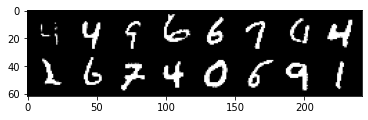

In [9]:
# Training
ae = AE().to(device)
loss_function = nn.BCEWithLogitsLoss()
opt = torch.optim.Adam(ae.parameters())

# Loop 
for _ in (t := trange(2)):
    for x, _ in loader:
        x = x.view(-1, 784)
        x = x.to(device)
        out = ae(x)
        loss = loss_function(out, x)

        opt.zero_grad()
        loss.backward()
        opt.step()
    
    print(f"Gen_loss = {loss.item():.2f}")
    out = out.view(16, -1, 28, 28).cpu().detach()
    plot_gen_image(out)
   
    